# Stage 5: Machine Learning Diagnostic Model Construction

**Version**: V4.7

### Input Data
- Stage 2: `discovery_data_corrected`, `moscow_data_clr`, and group information
- Stage4: `sig_taxa`, `sig_pathways`, `sig_genes`, `sig_ecs`

### Validation Strategy
- **Internal validation**: 5-fold nested CV on the discovery cohort (n=471)
- **External validation**: Cross-ethnic validation on the Moscow cohort (n=74)

### Expected Results
- Internal validation: AUC ≈ 0.85-0.90
- External validation: AUC ≈ 0.50-0.60 (population-specific)


## 5.1 Data Loading (Discovery + Validation)

In [1]:
# ============================================================
# Cell 1: Initialization and data loading (V5.1 revised version)
# ============================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder

from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✓ Google Drive 已挂载")

# 1. Define paths
BASE_PATH = '/content/drive/MyDrive/ASD_Research'
DATA_PATH = os.path.join(BASE_PATH, '02_merged_data')
FIG_PATH = os.path.join(BASE_PATH, '04_figures')
os.makedirs(FIG_PATH, exist_ok=True)

# 2. Load Stage 2 data
print("正在加载 Stage 2 数据...")
pkl_path = os.path.join(DATA_PATH, 'stage2_normalized_data.pkl')

if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        stage2_data = pickle.load(f)

    # --- Critical fix: read the correct variable names ---

    # 1. Discovery cohort data
    discovery_data = stage2_data['discovery_data_corrected']
    discovery_group = stage2_data['discovery_group']

    # 2. Batch information (for LOSO validation)
    # The key saved in Stage 2 is 'discovery_study'
    if 'discovery_study' in stage2_data:
        discovery_study = stage2_data['discovery_study']
        print(f"  ✅ 成功加载 StudyID 信息 (用于 LOSO, N={len(discovery_study)})")
        print(f"     包含队列: {discovery_study.unique()}")
    else:
        print("  ⚠ 警告: 未找到 'discovery_study' 变量，尝试查找其他 Key...")
        # Fallback: print all keys for inspection
        print(f"     可用 Keys: {stage2_data.keys()}")
        discovery_study = None

    # 3. External validation data (Moscow)
    # The key saved in Stage 2 may be 'validation_data_corrected' or 'moscow_data_clr'
    if 'validation_data_corrected' in stage2_data:
        validation_data = stage2_data['validation_data_corrected']
        validation_group = stage2_data['validation_group']
        print(f"  ✅ 成功加载外部验证数据 (N={len(validation_group)})")
    elif 'moscow_data_clr' in stage2_data: # 兼容旧版命名
        validation_data = stage2_data['moscow_data_clr']
        # Moscow group labels are usually handled in Stage 1; if no dedicated validation_group exists, they may need to be created manually
        # This assumes that 'validation_group' or 'moscow_group' exists
        validation_group = stage2_data.get('validation_group', stage2_data.get('moscow_group'))
        print(f"  ✅ 成功加载外部验证数据 (兼容模式, N={len(validation_group) if validation_group is not None else 0})")
    else:
        validation_data = None
        validation_group = None
        print("  ℹ 未找到外部验证数据")

else:
    raise FileNotFoundError(f"❌ 关键文件丢失: {pkl_path}")

# 3. Load Stage 4 feature lists
with open(os.path.join(DATA_PATH, 'stage4_diff_results.pkl'), 'rb') as f:
    stage4_results = pickle.load(f)
    target_features = stage4_results['sig_features_candidate']

print("\n✓ 数据准备就绪")
print(f"  - Discovery 样本: {len(discovery_group)}")
print(f"  - 特征列表 (Strict): {[len(v) for v in target_features.values()]}")

Mounted at /content/drive
✓ Google Drive 已挂载
正在加载 Stage 2 数据...
  ✅ 成功加载 StudyID 信息 (用于 LOSO, N=471)
     包含队列: ['Study_Dan2020' 'Study_Wang2019' 'Study_Xu2023' 'Study_Zhang2020'
 'Study_Tong2022' 'Study_CUHK' 'Local_Cohort']
  ✅ 成功加载外部验证数据 (兼容模式, N=74)

✓ 数据准备就绪
  - Discovery 样本: 471
  - 特征列表 (Strict): [4, 4, 5, 4]


## 5.2 Prepare the Feature Matrix

In [9]:
# ============================================================
# Cell 2: Robust feature matrix construction function
# Function: this is a critical utility that assembles irregular multi-omics data into a standard matrix and automatically handles missing features (for example, features absent in the Moscow cohort are filled with 0)
# ============================================================
def build_matrix_robust(data_dict, feature_dict, group_series, cohort_name="Unknown"):
    X_list = []
    for dtype, feats in feature_dict.items():
        if not feats: continue
        if dtype not in data_dict or data_dict[dtype] is None:
            df_zero = pd.DataFrame(0.0, index=feats, columns=group_series.index)
            X_list.append(df_zero.T)
            continue
        df_full = data_dict[dtype]
        if dtype == 'taxa':
            idx_keep = [i for i in df_full.index if 's__' in i and 't__' not in i]
            df_full = df_full.loc[idx_keep]
            df_full.index = [i.split('s__')[-1].replace('_', ' ') for i in df_full.index]
        existing = [f for f in feats if f in df_full.index]
        missing = [f for f in feats if f not in df_full.index]
        part_exist = df_full.loc[existing].T
        if missing:
            part_missing = pd.DataFrame(0.0, index=part_exist.index, columns=missing)
            part_combined = pd.concat([part_exist, part_missing], axis=1)
        else:
            part_combined = part_exist
        part_combined = part_combined[feats]
        part_combined.columns = [f"{dtype}|{c}" for c in part_combined.columns]
        X_list.append(part_combined)
    if not X_list: raise ValueError("没有特征可用于建模！")
    X_final = pd.concat(X_list, axis=1)
    common = X_final.index.intersection(group_series.index)
    X_final = X_final.loc[common]
    y_final = group_series.loc[common].map({'ASD': 1, 'TD': 0}).astype(int)
    return X_final, y_final
print("✓ 矩阵构建函数定义完成")

✓ 矩阵构建函数定义完成


## 5.3 Internal Validation (Nested CV)

🚀 任务1: 训练多组学模型 (Grid Search 自动寻优)

✅ 平均 AUC: 0.7694 ± 0.0497


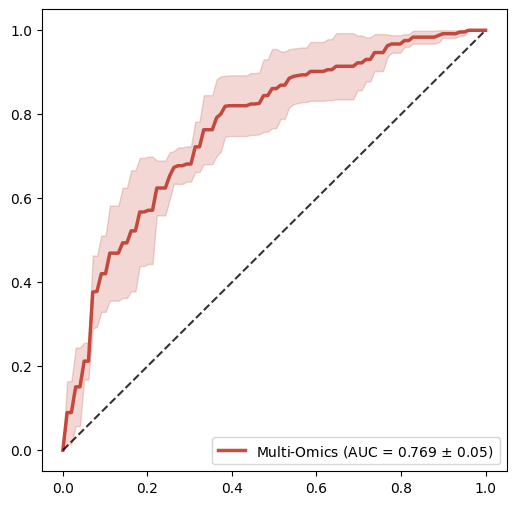

In [3]:
# ============================================================
# Cell 3: Main model training (GridSearch + nested CV)
# ============================================================
print("=" * 60)
print("🚀 任务1: 训练多组学模型 (Grid Search 自动寻优)")
print("=" * 60)
X, y = build_matrix_robust(discovery_data, target_features, discovery_group, "Discovery")
param_grid = {
    'n_estimators': [100, 300], 'max_depth': [None, 10],
    'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']
}
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
feature_importances = np.zeros(X.shape[1])
for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"Fold {i+1}/5 ...", end="\r")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    probas_ = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas_)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(auc(fpr, tpr))
    feature_importances += best_model.feature_importances_

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
feature_importances /= 5
print(f"\n✅ 平均 AUC: {mean_auc:.4f} ± {std_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(mean_fpr, mean_tpr, color='#C0392B', lw=2.5, alpha=.9, label=r'Multi-Omics (AUC = %0.3f $\pm$ %0.2f)' % (mean_auc, std_auc))
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='#C0392B', alpha=.2)
plt.plot([0, 1], [0, 1], 'k--', alpha=.8)
plt.legend(loc="lower right")
plt.savefig(os.path.join(FIG_PATH, 'Fig3B_ROC_Discovery.pdf'))
plt.show()

/tmp/ipython-input-585890504.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Label', data=feat_imp_df, palette='viridis')


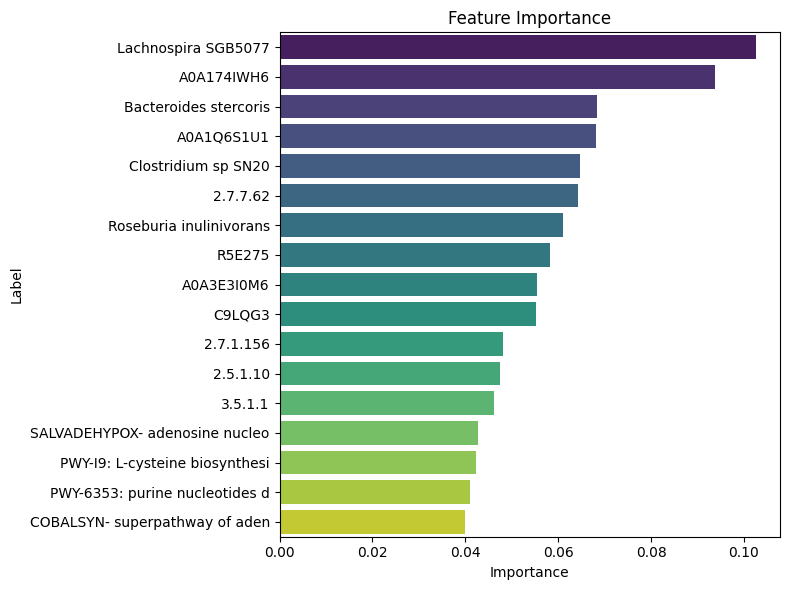

In [4]:
# ============================================================
# Cell 4: Feature importance
# ============================================================
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}).sort_values('Importance', ascending=False)
feat_imp_df['Label'] = feat_imp_df['Feature'].apply(lambda x: x.split('|')[1].replace('UniRef90_', '').replace('PWY:', '')[:30])
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Label', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'Fig3C_Feature_Importance.pdf'))
plt.show()

## 5.4 Single-Layer vs Multi-Omics Model Comparison

<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3999747285.py:54: SyntaxWarning: invalid escape sequence '\p'
  label_str = f'{rtype.capitalize()} (AUC = {mean_auc_sub:.3f} $\pm$ {std_auc_sub:.3f})'
/tmp/ipython-input-3999747285.py:62: SyntaxWarning: invalid escape sequence '\p'
  multi_label = f'Multi-Omics (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})'


🚀 任务2: 单组学 vs 多组学 ROC 曲线对比 (含标准差)
  - taxa      : AUC = 0.7459 ± 0.0488
  - pathways  : AUC = 0.6116 ± 0.0303
  - genes     : AUC = 0.7109 ± 0.0500
  - ecs       : AUC = 0.5505 ± 0.0356


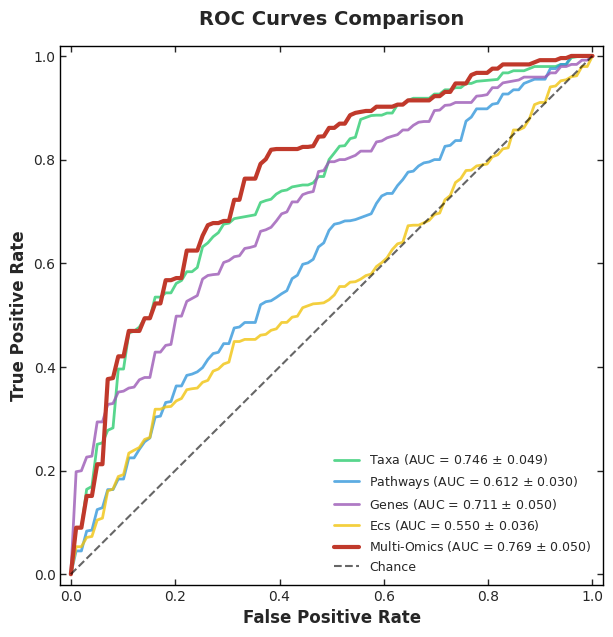


✓ 对比 ROC 曲线已保存: /content/drive/MyDrive/ASD_Research/04_figures/Fig3C_Model_Comparison_ROC.pdf


In [5]:
# ============================================================
# Cell 5: ROC comparison between single-omics and multi-omics models (with standard deviation ± SD)
# ============================================================
print("="*60)
print("🚀 任务2: 单组学 vs 多组学 ROC 曲线对比 (含标准差)")
print("="*60)

# 1. Check the results from Cell 3 (Mean and Std are reused here)
if 'mean_tpr' not in globals() or 'mean_auc' not in globals() or 'std_auc' not in globals():
    raise NameError("❌ 错误: 未找到 Cell 3 的完整结果(mean_auc/std_auc)。请务必先运行 Cell 3！")

# Set up the figure canvas
plt.figure(figsize=(7, 7))
sns.set_style("ticks")
plt.rcParams['axes.grid'] = False

colors = {
    'taxa': '#2ECC71',      # 绿色
    'pathways': '#3498DB',  # 蓝色
    'genes': '#9B59B6',     # 紫色
    'ecs': '#F1C40F',       # 黄色
}

mean_fpr_std = np.linspace(0, 1, 100)

# 2. Plot single-omics curves in a loop
for rtype in ['taxa', 'pathways', 'genes', 'ecs']:
    curr_feats = {rtype: target_features.get(rtype, [])}
    if sum(len(v) for v in curr_feats.values()) == 0: continue

    X_sub, y_sub = build_matrix_robust(discovery_data, curr_feats, discovery_group)

    # 5-Fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    tprs = []
    aucs = []
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

    for train, test in cv.split(X_sub, y_sub):
        rf.fit(X_sub.iloc[train], y_sub.iloc[train])
        probas_ = rf.predict_proba(X_sub.iloc[test])[:, 1]
        fpr, tpr, _ = roc_curve(y_sub.iloc[test], probas_)
        tprs.append(np.interp(mean_fpr_std, fpr, tpr))
        tprs[-1][0] = 0.0
        aucs.append(roc_auc_score(y_sub.iloc[test], probas_))

    # Compute the mean and standard deviation
    mean_tpr_sub = np.mean(tprs, axis=0)
    mean_tpr_sub[-1] = 1.0
    mean_auc_sub = auc(mean_fpr_std, mean_tpr_sub)
    std_auc_sub = np.std(aucs) # 计算标准差

    # Plot (include ± std in the label)
    label_str = f'{rtype.capitalize()} (AUC = {mean_auc_sub:.3f} $\pm$ {std_auc_sub:.3f})'
    plt.plot(mean_fpr_std, mean_tpr_sub, color=colors.get(rtype, 'gray'),
             label=label_str, lw=2.0, alpha=0.8)

    print(f"  - {rtype:<10}: AUC = {mean_auc_sub:.4f} ± {std_auc_sub:.4f}")

# 3. Plot the multi-omics curve (reusing Mean and Std from Cell 3)
# Note: std_auc comes from the global variables defined in Cell 3
multi_label = f'Multi-Omics (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})'

plt.plot(mean_fpr, mean_tpr, color='#C0392B',
         label=multi_label,
         lw=3.0, alpha=1.0)

# 4. Style the figure (Nature style)
plt.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='black', alpha=.6, label='Chance')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold', pad=15)

# Legend
plt.legend(loc="lower right", fontsize=9, frameon=False)

# Border and tick settings
ax = plt.gca()
ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

out_file = os.path.join(FIG_PATH, 'Fig3C_Model_Comparison_ROC.pdf')
plt.savefig(out_file, bbox_inches='tight')
plt.show()
print(f"\n✓ 对比 ROC 曲线已保存: {out_file}")

## 5.5 Leave-One-Study-Out Validation (LOSO)

🚀 任务3: 留一队列验证 (LOSO)
  检测到 7 个队列: ['Study_Dan2020' 'Study_Wang2019' 'Study_Xu2023' 'Study_Zhang2020'
 'Study_Tong2022' 'Study_CUHK' 'Local_Cohort']
  - Test on Study_Dan2020  : AUC = 0.837
  - Test on Study_Wang2019 : AUC = 0.895
  ⚠ 跳过 Study_Xu2023: 样本类别单一
  - Test on Study_Zhang2020: AUC = 0.723
  - Test on Study_Tong2022 : AUC = 0.716
  - Test on Study_CUHK     : AUC = 0.728
  - Test on Local_Cohort   : AUC = 0.636


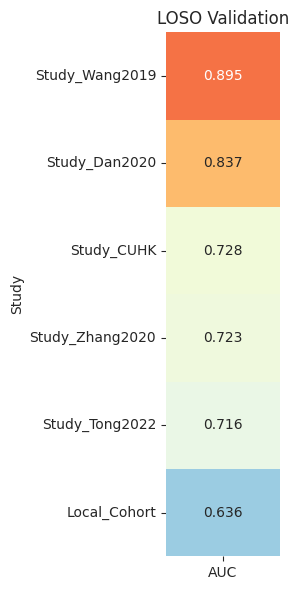

In [6]:
# ============================================================
# Cell 6: Leave-one-study-out validation (LOSO)
# ============================================================
print("="*60)
print("🚀 任务3: 留一队列验证 (LOSO)")
print("="*60)

# Check whether StudyID information is available
if 'discovery_study' in globals() and discovery_study is not None:
    # Prepare the full dataset
    X_full, y_full = build_matrix_robust(discovery_data, target_features, discovery_group, "Discovery")

    # Align StudyID values
    common = X_full.index.intersection(discovery_study.index)
    X_loso = X_full.loc[common]
    y_loso = y_full.loc[common]
    studies = discovery_study.loc[common]

    loso_results = []
    unique_studies = studies.unique()
    print(f"  检测到 {len(unique_studies)} 个队列: {unique_studies}")

    for study in unique_studies:
        train_mask = (studies != study)
        test_mask = (studies == study)

        X_train, y_train = X_loso[train_mask], y_loso[train_mask]
        X_test, y_test = X_loso[test_mask], y_loso[test_mask]

        # At least two classes are required to compute AUC
        if len(np.unique(y_loso[test_mask])) < 2:
            print(f"  ⚠ 跳过 {study}: 样本类别单一")
            continue

        rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        score = roc_auc_score(y_loso[test_mask], rf.predict_proba(X_loso[test_mask])[:, 1])

        loso_results.append({'Study': study, 'AUC': score})
        print(f"  - Test on {study:<15}: AUC = {score:.3f}")

    # Plot
    if loso_results:
        loso_df = pd.DataFrame(loso_results).set_index('Study').sort_values('AUC', ascending=False)
        plt.figure(figsize=(3, 6))
        sns.heatmap(loso_df, annot=True, cmap='RdYlBu_r', cbar=False, vmin=0.5, vmax=1.0, fmt=".3f")
        plt.title('LOSO Validation')
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_PATH, 'Fig3D_LOSO_Heatmap.pdf'))
        plt.show()
else:
    print("⚠ 跳过 LOSO: 未找到 StudyID 信息。")

## 5.6 Moscow External Validation and Result Saving

🚀 任务4: 莫斯科外部验证 & 最终保存
正在全量 Discovery 上确定最终最佳参数...
  最佳参数: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
  ✅ 莫斯科验证集 AUC: 0.4033


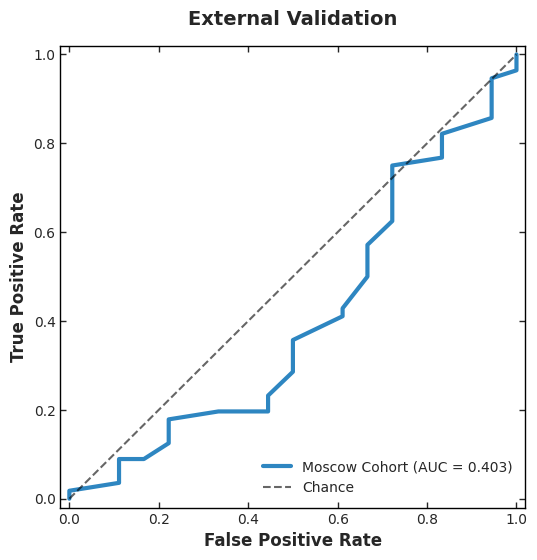


✓ Stage 5 全部任务完成，结果已保存！


In [8]:
# ============================================================
# Cell 7: External validation and result saving (final version)
# ============================================================
print("="*60)
print("🚀 任务4: 莫斯科外部验证 & 最终保存")
print("="*60)

# 1. Determine the best parameters by rerunning GridSearch on the full discovery cohort
print("正在全量 Discovery 上确定最终最佳参数...")
X_train, y_train = build_matrix_robust(discovery_data, target_features, discovery_group, "Discovery")

# The param_grid here must match the one used in Cell 3
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

final_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
final_grid.fit(X_train, y_train)
final_model = final_grid.best_estimator_
print(f"  最佳参数: {final_grid.best_params_}")

# 2. External validation (if data are available)
if 'validation_data' in globals() and validation_data is not None and validation_group is not None:
    X_test, y_test = build_matrix_robust(validation_data, target_features, validation_group, "Validation")
    # Align columns (fill missing features with 0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_pred = final_model.predict_proba(X_test)[:, 1]
    ext_auc = roc_auc_score(y_test, y_pred)
    print(f"  ✅ 莫斯科验证集 AUC: {ext_auc:.4f}")

    # --- Plotting (Nature style) ---
    fpr, tpr, _ = roc_curve(y_test, y_pred)

    plt.figure(figsize=(6, 6))
    sns.set_style("ticks")
    plt.rcParams['axes.grid'] = False

    # Plot the single ROC curve
    plt.plot(fpr, tpr, color='#2E86C1', lw=3, label=f'Moscow Cohort (AUC = {ext_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Chance')

    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('External Validation', fontsize=14, fontweight='bold', pad=15)

    plt.legend(loc="lower right", frameon=False, fontsize=10)

    # Border and tick settings (boxed style)
    ax = plt.gca()
    ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_edgecolor('black')

    plt.savefig(os.path.join(FIG_PATH, 'Fig3E_External_Validation.pdf'), bbox_inches='tight')
    plt.show()
else:
    print("⚠ 跳过外部验证: 未找到有效验证集数据。")
    ext_auc = None

# 3. Save
# Ensure that all core Stage 5 results are packaged and saved correctly for Stage 6
stage5_results = {
    'final_model': final_model,
    'best_params': final_grid.best_params_,
    'feature_list': target_features,
    'metrics': {'mean_auc_cv': mean_auc, 'external_auc': ext_auc}
}
with open(os.path.join(DATA_PATH, 'stage5_ml_results.pkl'), 'wb') as f:
    pickle.dump(stage5_results, f)

print("\n✓ Stage 5 全部任务完成，结果已保存！")